In [1]:
#setup-imports-and-paths
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import qutip as qt

from IPython.display import display, Math
import sympy as sp

#project-root-path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

#figures-folder-path
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

#outputs-folder-path
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIGURES_DIR)
print("Outputs folder:", OUTPUTS_DIR)
print("Notebook setup complete.")

Project root: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project
Figures folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures
Outputs folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs
Notebook setup complete.


In [2]:
#gamma0-decay-rate-into-free-space-parameter
gamma0 = 1.0

#gammac-decay-rate-into-cavity-parameter
alpha = 5.0
gammac = alpha * gamma0

#time-grid-dimensionless-time-tau-gamma0t
tau_min = 0.0
tau_max = 2.0
num_points = 500
tau_grid = np.linspace(tau_min, tau_max, num_points)

#physical-time-grid-t=tau/gamma0
t_grid = tau_grid / gamma0

print("gamma0 =", gamma0)
print("gammac =", gammac)
print("alpha = gammac/gamma0 =", alpha)
print("Using dimensionless time tau = gamma0 * t")

gamma0 = 1.0
gammac = 5.0
alpha = gammac/gamma0 = 5.0
Using dimensionless time tau = gamma0 * t


In [3]:
#latex-many-atom-master-equation-structure
display(Math(
    r"J_- = \sum_{i=1}^{N} \sigma_-^i"
))

display(Math(
    r"L_c = \sqrt{\Gamma_c}\,J_-"
))

display(Math(
    r"L_i = \sqrt{\Gamma_0}\,\sigma_-^i"
))

display(Math(
    r"P_e(t)=\sum_i \langle \sigma_{ee}^i(t)\rangle"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
#single-atom-basis-and-operators-qutip
ket_e_single = qt.basis(2, 0)
ket_g_single = qt.basis(2, 1)

#sigma-minus-single-atom-lowering-operator-calc
sigma_minus_single = ket_g_single * ket_e_single.dag()

#sigma-plus-single-atom-raising-operator-calc
sigma_plus_single = sigma_minus_single.dag()

#sigma-ee-single-atom-excited-population-operator-calc
sigma_ee_single = ket_e_single * ket_e_single.dag()

#identity-single-atom-operator-calc
identity_single = qt.qeye(2)

print("sigma_minus_single:")
print(sigma_minus_single)

print("sigma_ee_single:")
print(sigma_ee_single)

sigma_minus_single:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0.]
 [1. 0.]]
sigma_ee_single:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]


In [5]:
#many-atom-local-operator-builder
def local_operator(single_atom_operator, atom_index, num_atoms):
    """
    #local-operator-calc
    Places a single-atom operator on atom_index and identities on all other atoms.

    #atom-index-parameter
    atom_index uses Python indexing: 0, 1, 2, ..., N-1.

    #num-atoms-parameter
    Total number of two-level atoms.
    """
    
    #operator-list-calc
    operator_list = []
    
    for index in range(num_atoms):
        if index == atom_index:
            operator_list.append(single_atom_operator)
        else:
            operator_list.append(identity_single)
    
    #tensor-product-calc
    return qt.tensor(operator_list)

In [6]:
#many-atom-operators-builder
def build_many_atom_operators(num_atoms):
    """
    #many-atom-operators-calc
    Builds lowering operators, excited-state projectors, collective lowering operator,
    total excited population operator, and the initial all-excited state.
    """
    
    #local-lowering-operators-storage-calc
    sigma_minus_ops = [
        local_operator(sigma_minus_single, atom_index, num_atoms)
        for atom_index in range(num_atoms)
    ]
    
    #local-excited-population-operators-storage-calc
    sigma_ee_ops = [
        local_operator(sigma_ee_single, atom_index, num_atoms)
        for atom_index in range(num_atoms)
    ]
    
    #collective-lowering-operator-calc
    J_minus = sum(sigma_minus_ops)
    
    #total-excited-population-operator-calc
    total_excited_population_operator = sum(sigma_ee_ops)
    
    #initial-state-all-atoms-excited-calc
    psi0 = qt.tensor([ket_e_single for _ in range(num_atoms)])
    
    #initial-density-matrix-calc
    rho0 = psi0 * psi0.dag()
    
    return {
        "sigma_minus_ops": sigma_minus_ops,
        "sigma_ee_ops": sigma_ee_ops,
        "J_minus": J_minus,
        "total_excited_population_operator": total_excited_population_operator,
        "psi0": psi0,
        "rho0": rho0,
    }

In [7]:
#collapse-operators-builder
def build_collapse_operators(num_atoms, gamma0, gammac):
    """
    #collapse-operators-calc
    Builds collapse operators for collective cavity decay and independent free-space decay.

    #collective-cavity-decay
    L_c = sqrt(gammac) J_minus

    #independent-free-space-decay
    L_i = sqrt(gamma0) sigma_minus_i
    """
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #collapse-operators-storage-calc
    collapse_operators = []
    
    if gammac > 0:
        #collective-cavity-jump-operator-calc
        L_cavity = np.sqrt(gammac) * operators["J_minus"]
        collapse_operators.append(L_cavity)
    
    if gamma0 > 0:
        for sigma_minus_i in operators["sigma_minus_ops"]:
            #free-space-jump-operator-calc
            L_free_i = np.sqrt(gamma0) * sigma_minus_i
            collapse_operators.append(L_free_i)
    
    return collapse_operators

In [8]:
#solve-many-atom-master-equation-function
def solve_many_atom_master_equation(num_atoms, gamma0, gammac, t_grid):
    """
    #many-atom-master-equation-solver
    Solves the Lindblad master equation for N atoms.

    #output
    Returns total excited-state population as a function of time.
    """
    
    #many-atom-operators-calc
    operators = build_many_atom_operators(num_atoms)
    
    #hamiltonian-zero-because-resonant-no-hamiltonian-term
    dimension = 2 ** num_atoms
    H = 0 * qt.qeye([2 for _ in range(num_atoms)])
    
    #collapse-operators-calc
    collapse_operators = build_collapse_operators(num_atoms, gamma0, gammac)
    
    #expectation-operator-total-excited-population
    e_ops = [operators["total_excited_population_operator"]]
    
    print(f"Solving N = {num_atoms}")
    print(f"Hilbert dimension d = {dimension}")
    print(f"Density matrix entries d^2 = {dimension**2}")
    print(f"Number of collapse operators = {len(collapse_operators)}")
    
    #master-equation-solver-calc
    result = qt.mesolve(
        H,
        operators["rho0"],
        t_grid,
        collapse_operators,
        e_ops,
    )
    
    #total-excited-population-calc
    total_excited_population = np.real(result.expect[0])
    
    return total_excited_population

In [10]:
#sanity-check-N1-against-analytical-result
population_N1 = solve_many_atom_master_equation(
    num_atoms=1,
    gamma0=gamma0,
    gammac=gammac,
    t_grid=t_grid,
)

population_N1_analytical = np.exp(-(gamma0 + gammac) * t_grid)

max_error_N1 = np.max(np.abs(population_N1 - population_N1_analytical))

print("Maximum N=1 error:", max_error_N1)

Solving N = 1
Hilbert dimension d = 2
Density matrix entries d^2 = 4
Number of collapse operators = 2
Maximum N=1 error: 4.243802673442598e-07


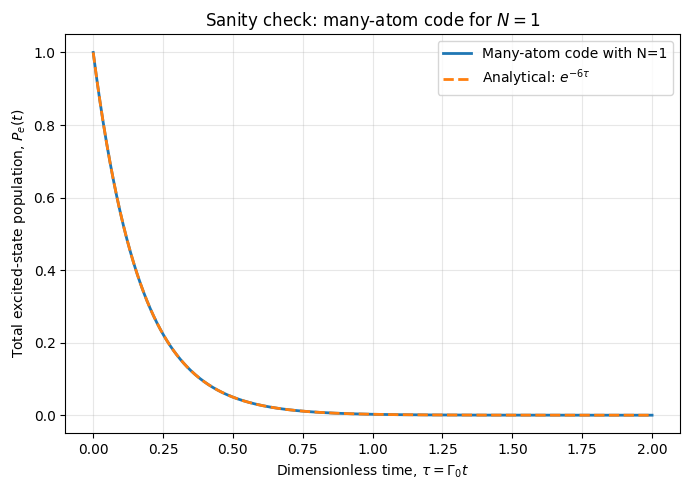

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_code_N1_sanity_check.png


In [11]:
#plot-N1-sanity-check
plt.figure(figsize=(7, 5))

plt.plot(
    tau_grid,
    population_N1,
    label="Many-atom code with N=1",
    linewidth=2,
)

plt.plot(
    tau_grid,
    population_N1_analytical,
    "--",
    label=r"Analytical: $e^{-6\tau}$",
    linewidth=2,
)

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Total excited-state population, $P_e(t)$")
plt.title(r"Sanity check: many-atom code for $N=1$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_code_N1_sanity_check.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [12]:
atom_numbers = [1, 2, 3, 4, 5, 6]

In [13]:
#solve-many-atom-populations-for-several-N
atom_numbers = [1, 2, 3, 4, 5, 6]

#many-atom-populations-storage-calc
many_atom_populations = {}

for num_atoms in atom_numbers:
    population = solve_many_atom_master_equation(
        num_atoms=num_atoms,
        gamma0=gamma0,
        gammac=gammac,
        t_grid=t_grid,
    )
    
    many_atom_populations[num_atoms] = population
    
    print(f"Finished N = {num_atoms}")

Solving N = 1
Hilbert dimension d = 2
Density matrix entries d^2 = 4
Number of collapse operators = 2
Finished N = 1
Solving N = 2
Hilbert dimension d = 4
Density matrix entries d^2 = 16
Number of collapse operators = 3
Finished N = 2
Solving N = 3
Hilbert dimension d = 8
Density matrix entries d^2 = 64
Number of collapse operators = 4
Finished N = 3
Solving N = 4
Hilbert dimension d = 16
Density matrix entries d^2 = 256
Number of collapse operators = 5
Finished N = 4
Solving N = 5
Hilbert dimension d = 32
Density matrix entries d^2 = 1024
Number of collapse operators = 6
Finished N = 5
Solving N = 6
Hilbert dimension d = 64
Density matrix entries d^2 = 4096
Number of collapse operators = 7
Finished N = 6


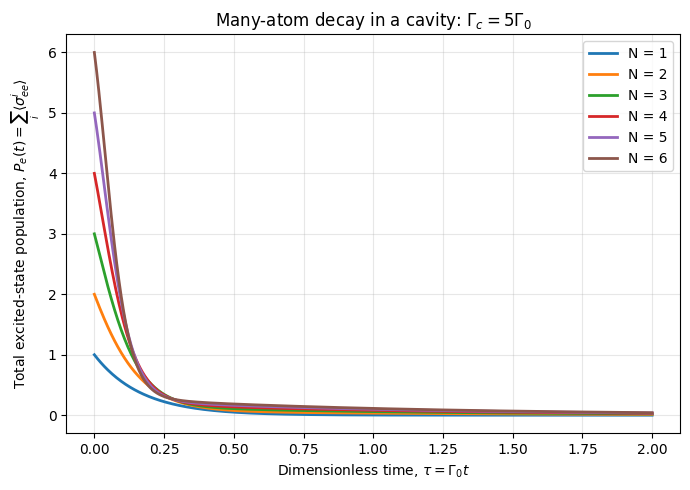

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_total_excited_population.png


In [14]:
#plot-total-excited-population-for-several-N
plt.figure(figsize=(7, 5))

for num_atoms in atom_numbers:
    plt.plot(
        tau_grid,
        many_atom_populations[num_atoms],
        linewidth=2,
        label=f"N = {num_atoms}",
    )

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Total excited-state population, $P_e(t)=\sum_i\langle\sigma_{ee}^i\rangle$")
plt.title(r"Many-atom decay in a cavity: $\Gamma_c = 5\Gamma_0$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_total_excited_population.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

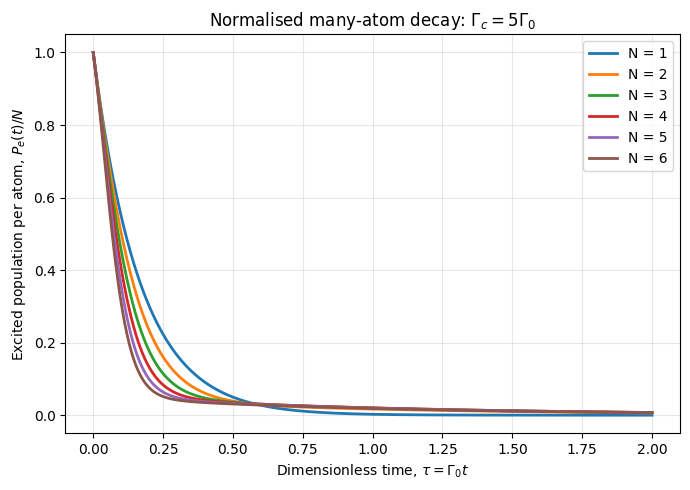

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_excited_population_per_atom.png


In [15]:
#plot-excited-population-per-atom
plt.figure(figsize=(7, 5))

for num_atoms in atom_numbers:
    plt.plot(
        tau_grid,
        many_atom_populations[num_atoms] / num_atoms,
        linewidth=2,
        label=f"N = {num_atoms}",
    )

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Excited population per atom, $P_e(t)/N$")
plt.title(r"Normalised many-atom decay: $\Gamma_c = 5\Gamma_0$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_excited_population_per_atom.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [16]:
#save-many-atom-results-table
results_df = pd.DataFrame({
    "tau": tau_grid
})

for num_atoms in atom_numbers:
    results_df[f"P_excited_N_{num_atoms}"] = many_atom_populations[num_atoms]

csv_path = OUTPUTS_DIR / "many_atom_master_equation_populations.csv"
results_df.to_csv(csv_path, index=False)

print("Saved results table to:", csv_path)
results_df.head()

Saved results table to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs\many_atom_master_equation_populations.csv


,tau,P_excited_N_1,P_excited_N_2,P_excited_N_3,P_excited_N_4,P_excited_N_5,P_excited_N_6
0,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000
1,0.004008,0.976239,1.952092,2.927551,3.902611,4.877261,5.851496
2,0.008016,0.953042,1.904602,2.854625,3.803056,4.749838,5.694912
3,0.012024,0.930397,1.857588,2.781410,3.701689,4.618246,5.530893
4,0.016032,0.908289,1.811105,2.708090,3.598870,4.483051,5.360219


In [17]:
#computational-scaling-check-direct-master-equation
import time

extra_atom_numbers = [7, 8, 9, 10]

timing_rows = []

for num_atoms in extra_atom_numbers:
    
    print("\n" + "=" * 50)
    print(f"Attempting N = {num_atoms}")
    
    start_time = time.time()
    
    try:
        population = solve_many_atom_master_equation(
            num_atoms=num_atoms,
            gamma0=gamma0,
            gammac=gammac,
            t_grid=t_grid,
        )
        
        elapsed_time = time.time() - start_time
        
        many_atom_populations[num_atoms] = population
        
        timing_rows.append({
            "N": num_atoms,
            "Hilbert dimension d=2^N": 2 ** num_atoms,
            "Density matrix entries d^2": (2 ** num_atoms) ** 2,
            "Runtime seconds": elapsed_time,
            "Status": "completed",
        })
        
        print(f"Finished N = {num_atoms} in {elapsed_time:.2f} seconds")
    
    except Exception as error:
        elapsed_time = time.time() - start_time
        
        timing_rows.append({
            "N": num_atoms,
            "Hilbert dimension d=2^N": 2 ** num_atoms,
            "Density matrix entries d^2": (2 ** num_atoms) ** 2,
            "Runtime seconds": elapsed_time,
            "Status": f"failed: {type(error).__name__}",
        })
        
        print(f"N = {num_atoms} failed after {elapsed_time:.2f} seconds")
        print("Error:", error)
        
        break

timing_table = pd.DataFrame(timing_rows)
timing_table


Attempting N = 7
Solving N = 7
Hilbert dimension d = 128
Density matrix entries d^2 = 16384
Number of collapse operators = 8


C:\Users\ivraa\miniforge31\envs\optics-me\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Finished N = 7 in 0.70 seconds

Attempting N = 8
Solving N = 8
Hilbert dimension d = 256
Density matrix entries d^2 = 65536
Number of collapse operators = 9
Finished N = 8 in 12.36 seconds

Attempting N = 9
Solving N = 9
Hilbert dimension d = 512
Density matrix entries d^2 = 262144
Number of collapse operators = 10
Finished N = 9 in 30.14 seconds

Attempting N = 10
Solving N = 10
Hilbert dimension d = 1024
Density matrix entries d^2 = 1048576
Number of collapse operators = 11
Finished N = 10 in 192.85 seconds


,N,Hilbert dimension d=2^N,Density matrix entries d^2,Runtime seconds,Status
0,7,128,16384,0.700451,completed
1,8,256,65536,12.362446,completed
2,9,512,262144,30.142750,completed
3,10,1024,1048576,192.845399,completed


In [18]:
#update-atom-number-list-after-extra-runs
atom_numbers = sorted(many_atom_populations.keys())
print("Available atom numbers:", atom_numbers)

Available atom numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [19]:
#save-computational-scaling-table
timing_csv_path = OUTPUTS_DIR / "direct_master_equation_timing.csv"
timing_table.to_csv(timing_csv_path, index=False)

print("Saved timing table to:", timing_csv_path)
timing_table

Saved timing table to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs\direct_master_equation_timing.csv


,N,Hilbert dimension d=2^N,Density matrix entries d^2,Runtime seconds,Status
0,7,128,16384,0.700451,completed
1,8,256,65536,12.362446,completed
2,9,512,262144,30.142750,completed
3,10,1024,1048576,192.845399,completed


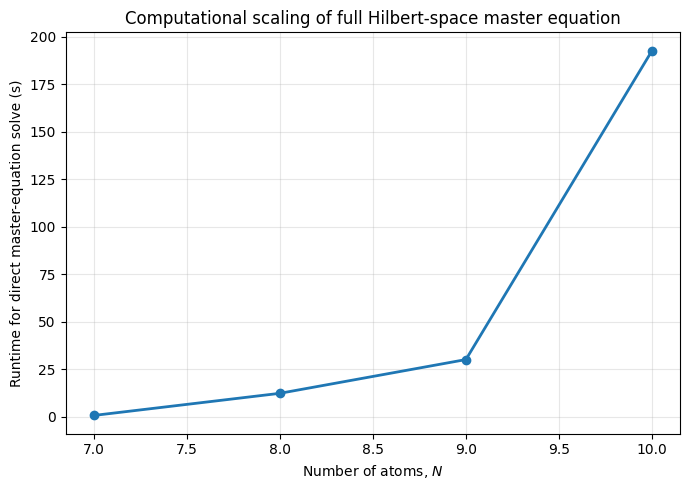

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\direct_master_equation_runtime_scaling.png


In [20]:
#plot-direct-master-equation-runtime-scaling
completed_timing = timing_table[timing_table["Status"] == "completed"]

plt.figure(figsize=(7, 5))

plt.plot(
    completed_timing["N"],
    completed_timing["Runtime seconds"],
    marker="o",
    linewidth=2,
)

plt.xlabel(r"Number of atoms, $N$")
plt.ylabel("Runtime for direct master-equation solve (s)")
plt.title("Computational scaling of full Hilbert-space master equation")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "direct_master_equation_runtime_scaling.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

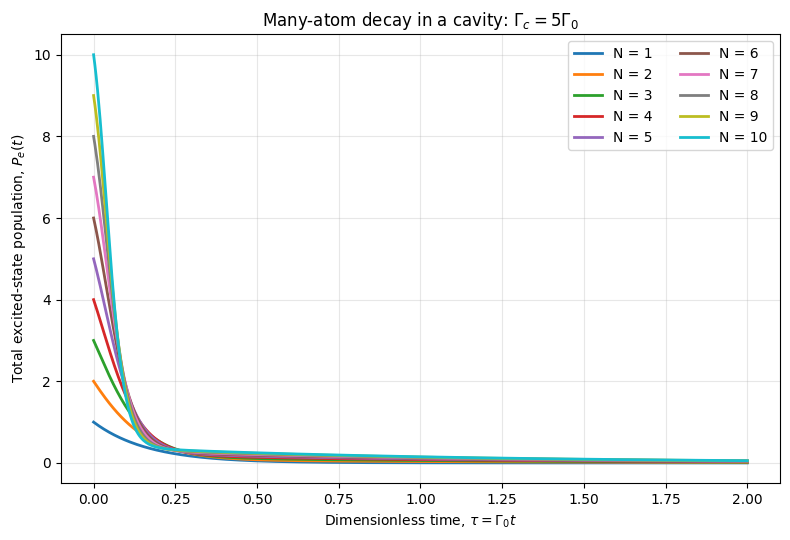

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_total_excited_population_N1_to_N10.png


In [21]:
#plot-total-excited-population-for-N1-to-N10
plt.figure(figsize=(8, 5.5))

for num_atoms in atom_numbers:
    plt.plot(
        tau_grid,
        many_atom_populations[num_atoms],
        linewidth=2,
        label=f"N = {num_atoms}",
    )

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Total excited-state population, $P_e(t)$")
plt.title(r"Many-atom decay in a cavity: $\Gamma_c = 5\Gamma_0$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_total_excited_population_N1_to_N10.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

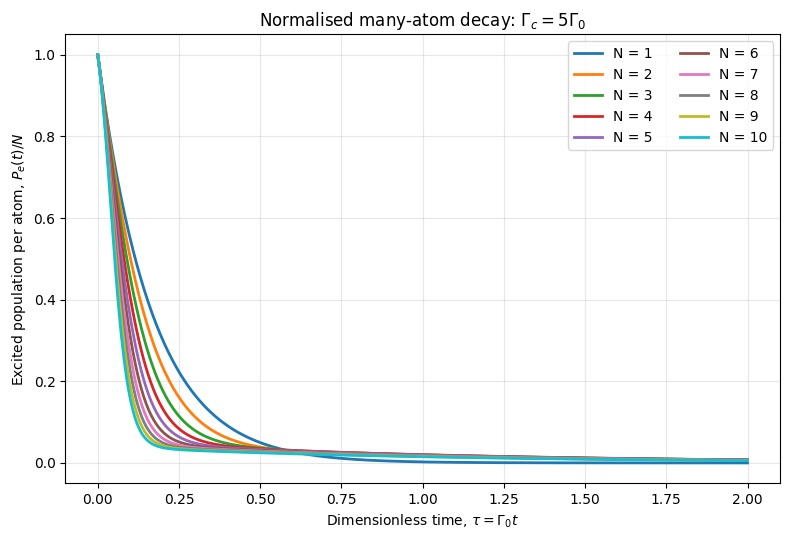

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\many_atom_excited_population_per_atom_N1_to_N10.png


In [22]:
#plot-excited-population-per-atom-N1-to-N10
plt.figure(figsize=(8, 5.5))

for num_atoms in atom_numbers:
    plt.plot(
        tau_grid,
        many_atom_populations[num_atoms] / num_atoms,
        linewidth=2,
        label=f"N = {num_atoms}",
    )

plt.xlabel(r"Dimensionless time, $\tau = \Gamma_0 t$")
plt.ylabel(r"Excited population per atom, $P_e(t)/N$")
plt.title(r"Normalised many-atom decay: $\Gamma_c = 5\Gamma_0$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "many_atom_excited_population_per_atom_N1_to_N10.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [23]:
#lighter-time-grid-for-large-N-tests
tau_grid_large = np.linspace(0.0, 2.0, 250)
t_grid_large = tau_grid_large / gamma0

print("Large-N test time points:", len(t_grid_large))

Large-N test time points: 250


In [24]:
#try-larger-N-direct-master-equation-carefully
import time

larger_atom_numbers = [11, 12, 13]

large_N_populations = {}

large_timing_rows = []

for num_atoms in larger_atom_numbers:
    
    print("\n" + "=" * 60)
    print(f"Attempting direct full-space master equation for N = {num_atoms}")
    print(f"Hilbert dimension d = {2 ** num_atoms}")
    print(f"Density matrix entries d^2 = {(2 ** num_atoms) ** 2}")
    
    start_time = time.time()
    
    try:
        population = solve_many_atom_master_equation(
            num_atoms=num_atoms,
            gamma0=gamma0,
            gammac=gammac,
            t_grid=t_grid_large,
        )
        
        elapsed_time = time.time() - start_time
        
        large_N_populations[num_atoms] = population
        
        large_timing_rows.append({
            "N": num_atoms,
            "Hilbert dimension d=2^N": 2 ** num_atoms,
            "Density matrix entries d^2": (2 ** num_atoms) ** 2,
            "Time points": len(t_grid_large),
            "Runtime seconds": elapsed_time,
            "Status": "completed",
        })
        
        #save-result-immediately
        np.save(
            OUTPUTS_DIR / f"population_direct_master_equation_N{num_atoms}.npy",
            population,
        )
        
        print(f"Finished N = {num_atoms} in {elapsed_time:.2f} seconds")
        print(f"Saved population for N = {num_atoms}")
    
    except Exception as error:
        elapsed_time = time.time() - start_time
        
        large_timing_rows.append({
            "N": num_atoms,
            "Hilbert dimension d=2^N": 2 ** num_atoms,
            "Density matrix entries d^2": (2 ** num_atoms) ** 2,
            "Time points": len(t_grid_large),
            "Runtime seconds": elapsed_time,
            "Status": f"failed: {type(error).__name__}",
        })
        
        print(f"N = {num_atoms} failed after {elapsed_time:.2f} seconds")
        print("Error:", error)
        
        break

large_timing_table = pd.DataFrame(large_timing_rows)
large_timing_table


Attempting direct full-space master equation for N = 11
Hilbert dimension d = 2048
Density matrix entries d^2 = 4194304
Solving N = 11
Hilbert dimension d = 2048
Density matrix entries d^2 = 4194304
Number of collapse operators = 12


C:\Users\ivraa\miniforge31\envs\optics-me\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Finished N = 11 in 1180.67 seconds
Saved population for N = 11

Attempting direct full-space master equation for N = 12
Hilbert dimension d = 4096
Density matrix entries d^2 = 16777216
Solving N = 12
Hilbert dimension d = 4096
Density matrix entries d^2 = 16777216
Number of collapse operators = 13
N = 12 failed after 242.54 seconds
Error: Failed to allocate the `data` of a (16777216, 16777216) CSR array of 1744822272 max elements.


,N,Hilbert dimension d=2^N,Density matrix entries d^2,Time points,Runtime seconds,Status
0,11,2048,4194304,250,1180.667358,completed
1,12,4096,16777216,250,242.536132,failed: MemoryError
